In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# State 정의
class State(TypedDict):
    message: str


# Node
def hello(state: State):

    #print("Hello World!")
    #print(state.messaage) #에러남
    print(state["message"])   # Dictionary는 []로 접근
    return state


# Graph 생성
builder = StateGraph(State)

builder.add_node("hello", hello)

builder.add_edge(START, "hello")
builder.add_edge("hello", END)

graph = builder.compile()


# 실행
graph.invoke({
    "message": "hello world!"
})

Hello World!
hello world!


{'message': 'hello world!'}

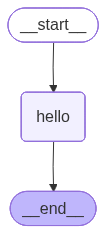

In [7]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
from typing import TypedDict

from langgraph.graph import (
    StateGraph,
    START,
    END
)

# ==================================
# 1. State 정의
# ==================================

class State(TypedDict):

    question: str

    search_result: str

    answer: str



# ==================================
# 2. Question Node
# ==================================

def question_node(state: State):

    print("\n[Question Node]")

    print(
        "질문:",
        state["question"]
    )

    #LangGraph에서는 Node가 반환한 값은 전체 State가 아니라 "변경할 부분(update)"
    
    return {
        # 변경 없음
    }


# ==================================
# 3. Search Node
# ==================================

def search_node(state: State):

    print("\n[Search Node]")

    question = state["question"]


    print(
        f"{question} 검색 중..."
    )


    search_result = (
        "LangGraph는 "
        "LLM Workflow를 만드는 "
        "Graph 기반 Framework입니다."
    )


    return {

        "search_result":
        search_result

    }



# ==================================
# 4. Answer Node
# ==================================

def answer_node(state: State):

    print("\n[Answer Node]")


    question = state["question"]

    context = state["search_result"]


    answer = f"""
질문:
{question}

검색 결과:
{context}

답변:
LangGraph는 Node와 Edge를 이용하여 
Agent Workflow를 만드는 기술입니다.
"""


    return {

        "answer":
        answer

    }



# ==================================
# 5. Output Node
# ==================================

def output_node(state: State):

    print("\n[Output Node]")


    print("===================")

    print(state["answer"])

    print("===================")


    return {}



# ==================================
# 6. Graph Builder
# ==================================

builder = StateGraph(State)



# Node 등록

builder.add_node(
    "question",
    question_node
)


builder.add_node(
    "search",
    search_node
)


builder.add_node(
    "answer",
    answer_node
)


builder.add_node(
    "output",
    output_node
)



# Edge 연결

builder.add_edge(
    START,
    "question"
)


builder.add_edge(
    "question",
    "search"
)


builder.add_edge(
    "search",
    "answer"
)


builder.add_edge(
    "answer",
    "output"
)


builder.add_edge(
    "output",
    END
)



# Compile

graph = builder.compile()



# ==================================
# 7. 실행
# ==================================

result = graph.invoke(

    {
        "question":
        "LangGraph란 무엇인가?",

        "search_result":
        "",

        "answer":
        ""
    }

)


print("\n최종 State")

print(result)


[Question Node]
질문: LangGraph란 무엇인가?

[Search Node]
LangGraph란 무엇인가? 검색 중...

[Answer Node]

[Output Node]

질문:
LangGraph란 무엇인가?

검색 결과:
LangGraph는 LLM Workflow를 만드는 Graph 기반 Framework입니다.

답변:
LangGraph는 Node와 Edge를 이용하여 
Agent Workflow를 만드는 기술입니다.


최종 State
{'question': 'LangGraph란 무엇인가?', 'search_result': 'LangGraph는 LLM Workflow를 만드는 Graph 기반 Framework입니다.', 'answer': '\n질문:\nLangGraph란 무엇인가?\n\n검색 결과:\nLangGraph는 LLM Workflow를 만드는 Graph 기반 Framework입니다.\n\n답변:\nLangGraph는 Node와 Edge를 이용하여 \nAgent Workflow를 만드는 기술입니다.\n'}


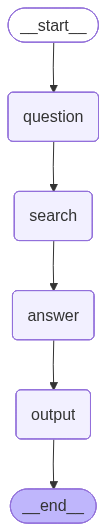

In [2]:
from IPython.display import Image, display


display(
    Image(
        graph.get_graph()
        .draw_mermaid_png()
    )
)